# MERG v2 — H1 Event-Direction Gate (Y_sell_h1)

**Purpose:** Predict whether EURUSD will be **lower (SELL)** over the next 4–6 H1 hours
following a high-impact economic release, using only pre-event M1 candlestick microstructure.

> This model replaces the failed M1-direction Stage 2 (ROC-AUC 0.490 → noise). The immediate
> M1 direction is a coin flip, but the **multi-hour** direction after a release might carry real
> signal from the pre-event positioning reflected in the M1 candles.

**Target (`Y`):** a path-dependent SELL label derived from H1 OHLCV data, anchored to the event
bar's close — see the dedicated *"Target variable"* section.

**Place in the pipeline:**
```
H1 SELL signal fires (daily routine)
    ↓
MERG Stage 1:  P(reaction) ≥ 0.60?   (volatility coming?)
    NO  → PASS to agents normally
    YES → THIS MODEL:  "Will EURUSD be DOWN over next 6 H1 hours?"
              DOWN → SELL aligned → PASS (trade proceeds)
              UP   → SELL contradicted → BLOCK (veto)
```

**Dataset:** same `ExportedData.csv` features + `EURUSD_H1.csv` OHLCV data for the target.
The H1 file starts in 2019, so only ~2,500 events are annotated. If this model shows signal,
fetching earlier H1 data from MT5 would roughly double the training set.

**Pipeline overview:**
1. Configuration (paths, window prefix, TP/SL params, split dates)
2. Load + join MERG events with H1 OHLCV data
3. Target variable explanation → build `y_sell_h1` (TP/SL path label)
4. Feature engineering (candle anatomy + derived ratios, gated by `WINDOW_PREFIX`)
5. Event handling (frequency filter + one-hot top-N + speech flag)
6. Chronological split → train / val / test (test sealed)
7. Feature selection (noise-injection voting)
8. Model selection (purged nested CV + recency weights)
9. Final model (isotonic calibration + soft-vote ensemble)
10. Threshold calibration (F1-optimal on validation)
11. Sealed test evaluation (ROC-AUC / PR-AUC / per-event / speech breakdown)
12. Save bundle to `models_bin/`


In [5]:
# ── Core imports ────────────────────────────────────────────────────────────────
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Python  : {sys.version}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")


Python  : 3.11.11 | packaged by conda-forge | (main, Mar  3 2025, 20:29:43) [MSC v.1943 64 bit (AMD64)]
NumPy   : 2.0.2
Pandas  : 2.2.2


## 1. Configuration

All paths and key parameters live in one place. Change `WINDOW_PREFIX`, the split dates, TP/SL
multipliers, or the forward H1 horizon here — every downstream cell reads from these.


In [6]:
from pathlib import Path

# ── Instrument & dataset ────────────────────────────────────────────────────────
PAIR      = "EURUSD"     # the exported dataset is EURUSD-only
TIMEFRAME = "M1"         # the 15 pre-event windows are 1-minute bars

# ── Paths ───────────────────────────────────────────────────────────────────────
ROOT = Path("../..").resolve()            # root of ml-signal-service (two levels up)

RAW_FILE      = ROOT / "data" / "raw" / "macro" / "ExportedData.csv"
H1_OHLCV_FILE = ROOT / "data" / "raw" / "mt5" / "H1" / "EURUSD_H1.csv"
MODELS_DIR    = ROOT / "models_bin"
FEATURES_DIR  = ROOT / "data" / "features"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Leak-free window prefix ─────────────────────────────────────────────────────
# The 15 windows are anchored to the release moment:
#
#     window 15..11  = 5 pre-event bars
#     window 10      = the release bar (the minute the news prints)
#     window 9..1    = 10 post-event bars  ← NOT usable for a forward prediction
#
# WINDOW_PREFIX = how many windows (counting back from 15) the model may see.
#     5  = pre-event bars only (true blind prediction)   ← default, leak-free
#     6  = + the release bar       7 = +1 post bar     10 = +5 post bars
#     15 = all bars (leaky)
WINDOW_PREFIX = 5

# ── Event handling ──────────────────────────────────────────────────────────────
# Same filter as the MERG Stage-1 notebook (events with too few occurrences in TRAIN
# cannot be learned from). Apply on the joined event+H1 dataset.
EVENT_MIN_COUNT = 10
EVENT_TOP_K     = 20

# ── TP / SL parameters (mirror the EURUSD SELL notebook) ────────────────────────
ATR_PERIOD      = 14
TP_MULTIPLIER   = 2.0     # TP = entry − ATR × TP_MULT (below entry for a SELL)
SL_MULTIPLIER   = 1.25    # SL = entry + ATR × SL_MULT (above entry for a SELL)
FORWARD_BARS    = 6       # look ahead this many H1 bars from the event bar

# ── Chronological split boundaries ──────────────────────────────────────────────
TRAIN_END = "2023-01-01"
VAL_END   = "2024-01-01"

# ── CV / training knobs ─────────────────────────────────────────────────────────
OUTER_FOLDS   = 5
INNER_FOLDS   = 4
PURGE_DAYS    = 30
SEARCH_ITERS  = 60
RECENCY_DECAY = 0.15

# ── Gate operating threshold ──────────────────────────────────────────────────
# The TP/SL label is typically imbalanced (~30–40% SELL). The F1-optimal threshold
# is tuned on validation and saved in the bundle as `threshold_f1_optimal`. The
# runtime gate will use a HIGH-confidence cutoff (e.g. 0.60) applied to P(SELL),
# consistent with MERG Stage 1.
GATE_THRESHOLD = 0.60

print(f"Pair          : {PAIR}")
print(f"Raw file      : {RAW_FILE}  (exists={RAW_FILE.exists()})")
print(f"H1 OHLCV      : {H1_OHLCV_FILE}  (exists={H1_OHLCV_FILE.exists()})")
print(f"Window prefix : {WINDOW_PREFIX}")
print(f"TP multiplier : {TP_MULTIPLIER}xATR  |  SL multiplier : {SL_MULTIPLIER}xATR")
print(f"Forward bars  : {FORWARD_BARS} H1")
print(f"Gate threshold: {GATE_THRESHOLD}")
print(f"Train         : < {TRAIN_END}  |  Val : {TRAIN_END} → {VAL_END}  |  Test : >= {VAL_END}")


Pair          : EURUSD
Raw file      : C:\Users\david\OneDrive\Documents\fx-prival\ml-signal-service\data\raw\macro\ExportedData.csv  (exists=True)
H1 OHLCV      : C:\Users\david\OneDrive\Documents\fx-prival\ml-signal-service\data\raw\mt5\H1\EURUSD_H1.csv  (exists=True)
Window prefix : 5
TP multiplier : 2.0xATR  |  SL multiplier : 1.25xATR
Forward bars  : 6 H1
Gate threshold: 0.6
Train         : < 2023-01-01  |  Val : 2023-01-01 → 2024-01-01  |  Test : >= 2024-01-01


## 2. Load Data & Join with H1 OHLCV

We load two data sources and join them on time:

1. **MERG events** (`ExportedData.csv`) — one row per high-impact release with M1 candle anatomy
2. **H1 OHLCV bars** (`EURUSD_H1.csv`) — hourly open/high/low/close from MT5 (2019+)

The join maps every event to the H1 bar that contains its release minute. The H1 bar's close is
the entry price for the forward TP/SL label.

> The H1 file on disk starts at 2019, so ~2,300 pre-2019 events drop out. The training set will
> be ~2,500 annotated events. Fetch earlier H1 data from MT5 to reclaim the full 4,793 if needed.


In [7]:
# ── Load MERG events ──────────────────────────────────────────────────────────
df = pd.read_csv(RAW_FILE)
df["time"] = pd.to_datetime(df["time"], format="%Y.%m.%d %H:%M")
df = df.sort_values("time").reset_index(drop=True)
print(f"MERG events : {len(df):,}  ({df['time'].min()}  →  {df['time'].max()})")

# ── Load H1 OHLCV ──────────────────────────────────────────────────────────────
h1 = pd.read_csv(H1_OHLCV_FILE)
h1["datetime"] = pd.to_datetime(h1["datetime"])
h1 = h1.sort_values("datetime").reset_index(drop=True)
print(f"H1 bars     : {len(h1):,}  ({h1['datetime'].min()}  →  {h1['datetime'].max()})")

# ── Compute ATR(14) on H1 bars BEFORE the join (so it carries into the merged df) ─
h1["tr"] = np.maximum(
    h1["high"] - h1["low"],
    np.maximum(
        abs(h1["high"] - h1["close"].shift(1)),
        abs(h1["low"]  - h1["close"].shift(1)),
    ),
)
h1["atr"] = h1["tr"].rolling(ATR_PERIOD, min_periods=ATR_PERIOD).mean()
h1 = h1.drop(columns=["tr"])

# ── Join: map each event to its containing H1 bar (atr comes with it) ───────────
df["event_hour"] = df["time"].dt.floor("h")
df = df.merge(h1, left_on="event_hour", right_on="datetime", how="inner", suffixes=("", "_h1"))
df = df.sort_values("datetime").reset_index(drop=True)
print(f"Joined      : {len(df):,} events matched a H1 bar")
print(f"Date range  : {df['datetime'].min()}  →  {df['datetime'].max()}")


MERG events : 4,793  (2007-02-13 13:00:00  →  2026-07-31 15:30:00)
H1 bars     : 47,231  (2019-01-02 00:00:00  →  2026-08-04 21:00:00)
Joined      : 2,473 events matched a H1 bar
Date range  : 2019-01-03 18:00:00  →  2026-07-31 15:00:00


## 3. Target variable — `y_sell_h1` (the path-dependent SELL label)

### What we predict

For each high-impact event we ask: *"After this release, will EURUSD move DOWN far enough to
hit a TP (take-profit) before it moves UP far enough to hit an SL (stop-loss)?"*

The label is exactly the same path-dependent SELL/SL logic the H1 trading models use — but
anchored to the event bar's close instead of an arbitrary H1 bar.

### How the label is computed

1. **Entry** = close of the H1 bar that contains the event minute.
2. **ATR(14)** = rolling average true range over the 14 preceding H1 bars (no forward leak).
3. **TP level** = entry − `TP_MULTIPLIER × ATR`  (the price target BELOW entry for a SELL).
4. **SL level** = entry + `SL_MULTIPLIER × ATR`  (the stop-loss ABOVE entry for a SELL).
5. Look at the next `FORWARD_BARS` H1 bars. If **low ≤ TP** occurs before **high ≥ SL**, the
   SELL wins → `y_sell_h1 = 1`. Otherwise (SL hit first, or neither hit) → `y_sell_h1 = 0`.

### Why path-dependent (not net return)

Net return over 6 hours (`close[t+6] − close[t]`) ignores the path — a big whipsaw that hits both
SL and TP would look neutral on net return but is a real loser on the SL side. The TP/SL label
correctly captures the *tradeable* outcome: did the move go far enough in the right direction
before going far enough in the wrong one?

### Class balance

The TP/SL label is typically imbalanced (the SL side wins more often than the TP side, because
stops are tighter than targets). Expect a positive rate around 30–40%. A model that simply
predicts "no SELL" every time would have ~60–70% accuracy — so we optimise PR-AUC, not accuracy.

### The leakage distinction

- `y_sell_h1` is the **outcome** — the H1 bars *after* the event determine it. That's fine: it
  is the thing we predict.
- All **features** are the pre-event M1 candle anatomy + event identity — available *before* the
  release. Nothing in the feature vector sees the post-event H1 bars.


In [8]:
# ── Build the SELL label per event ─────────────────────────────────────────────
# For each event row (already joined with its H1 bar and ATR):
#   entry = close of the H1 bar containing the event
#   tp    = entry - ATR * TP_MULT
#   sl    = entry + ATR * SL_MULT
#   Look at the next FORWARD_BARS H1 bars (low/tp, high/sl).  If tp hit first → y=1.
#   The ATR was computed on the H1 dataframe BEFORE the merge and carried into df.

y_labels = np.full(len(df), np.nan)
n_missing_atr = 0
n_missing_data = 0

# Build a fast lookup from datetime to row index in the H1 dataframe
h1_index = {ts: i for i, ts in enumerate(h1["datetime"])}

for idx in range(len(df)):
    event_dt = df.loc[idx, "datetime"]       # H1 bar datetime of this event
    atr_val  = df.loc[idx, "atr"]
    entry    = df.loc[idx, "close"]
    h1_pos   = h1_index.get(event_dt, -1)
    if h1_pos < 0:
        n_missing_data += 1
        continue
    if pd.isna(atr_val) or atr_val <= 0:
        n_missing_atr += 1
        continue

    tp = entry - atr_val * TP_MULTIPLIER
    sl = entry + atr_val * SL_MULTIPLIER

    # Scan the next FORWARD_BARS H1 bars
    tp_hit, sl_hit = False, False
    for fwd in range(1, FORWARD_BARS + 1):
        fwd_pos = h1_pos + fwd
        if fwd_pos >= len(h1):
            break
        bar_low  = h1.loc[fwd_pos, "low"]
        bar_high = h1.loc[fwd_pos, "high"]
        if bar_low <= tp:
            tp_hit = True
            break
        if bar_high >= sl:
            sl_hit = True
            break

    if tp_hit and not sl_hit:
        y_labels[idx] = 1
    else:
        y_labels[idx] = 0

df["y_sell_h1"] = y_labels.astype(float)

valid = df["y_sell_h1"].notna()
df = df[valid].reset_index(drop=True)
print(f"Dropped {n_missing_atr} rows (missing ATR) + {int((~valid).sum()) - n_missing_atr} (no forward data)")
print(f"Annotated events : {len(df):,}")

print("\n=== y_sell_h1 (H1 event-direction label) ===")
print(df["y_sell_h1"].value_counts(normalize=True).round(4).to_string())
print(f"\nPositive rate (SELL) : {df['y_sell_h1'].mean()*100:.1f}%")
print(f"Majority baseline   : {max(df['y_sell_h1'].mean(), 1 - df['y_sell_h1'].mean())*100:.1f}%")
print("→ a useful model must beat the majority baseline on PR-AUC.")


Dropped 0 rows (missing ATR) + 0 (no forward data)
Annotated events : 2,473

=== y_sell_h1 (H1 event-direction label) ===
y_sell_h1
0.0    0.7428
1.0    0.2572

Positive rate (SELL) : 25.7%
Majority baseline   : 74.3%
→ a useful model must beat the majority baseline on PR-AUC.


## 4. Feature Engineering

The raw data is *already* feature data (candle anatomy), so — unlike the EURUSD notebooks — there
is no OHLCV→indicator pipeline. Two things remain:

1. **Window-prefix gating** — keep only the `WINDOW_PREFIX` pre-event windows (leak-free).
2. **Derived shape ratios** — per-bar ratios that describe *shape* independent of scale, plus a
   few cross-window aggregates computed over the active (pre-event) windows only.


In [9]:
# ── Window numbering reminder ───────────────────────────────────────────────────
#   15  14  13  12  11 | 10 |  9  8  7  6  5  4  3  2  1
#   ─── pre-event ──── | rel| ─── post-event (leaky) ───
# WINDOW_PREFIX selects the first `prefix` windows counting back from 15.

def active_windows(prefix):
    """Return the window indices the model may see, high→low.
    prefix=5 → [15,14,13,12,11]; prefix=6 → [... ,10]; prefix=15 → [15..1]."""
    return list(range(15, 15 - prefix, -1))


def build_features(data, prefix):
    """Build the leak-free feature matrix from raw candle anatomy.

    For every active window `i` we keep the raw (tWick, body, bWick) triple and derive
    three shape ratios that describe the bar independently of its absolute price level
    (the dataset is already price-normalised, but these make the model scale-robust):

        range_i      = tWick_i + |body_i| + bWick_i      (total candle length)
        body_ratio_i = |body_i| / range_i                (body vs wick share)
        wick_asym_i  = (tWick_i - bWick_i) / range_i     (upper vs lower wick bias)

    We then add a few cross-window aggregates (sum / mean / std) over the active windows.
    All transforms are row-wise or within-row aggregates over the pre-event window set,
    so nothing looks into the future.
    """
    df = data.copy()
    wins = active_windows(prefix)

    raw_cols, derived_cols = [], []
    for i in wins:
        t, b, bw = f"tWick{i}", f"body{i}", f"bWick{i}"
        raw_cols += [t, b, bw]

        rng = df[t] + df[b].abs() + df[bw]
        # guard flat bars (range==0) → define ratios as 0 instead of dividing by zero
        df[f"range_{i}"]      = rng
        df[f"body_ratio_{i}"] = (df[b].abs() / rng.replace(0, np.nan)).fillna(0)
        df[f"wick_asym_{i}"]  = ((df[t] - df[bw]) / rng.replace(0, np.nan)).fillna(0)
        derived_cols += [f"range_{i}", f"body_ratio_{i}", f"wick_asym_{i}"]

    # ── Cross-window aggregates (order-independent, pre-event only) ──────────────
    body_all  = df[[f"body{i}" for i in wins]]
    asym_all  = df[[f"wick_asym_{i}" for i in wins]]
    range_all = df[[f"range_{i}" for i in wins]]

    df["body_sum"]       = body_all.sum(axis=1)
    df["body_mean"]      = body_all.mean(axis=1)
    df["body_abs_sum"]   = body_all.abs().sum(axis=1)
    df["body_std"]       = body_all.std(axis=1).fillna(0)
    df["wick_asym_mean"] = asym_all.mean(axis=1)
    df["range_sum"]      = range_all.sum(axis=1)
    df["range_mean"]     = range_all.mean(axis=1)

    feature_cols = raw_cols + derived_cols + [
        "body_sum", "body_mean", "body_abs_sum", "body_std",
        "wick_asym_mean", "range_sum", "range_mean",
    ]
    return df, feature_cols


df, FEATURE_COLS = build_features(df, WINDOW_PREFIX)

print(f"Active windows   : {active_windows(WINDOW_PREFIX)}")
print(f"Anatomy features : {len(FEATURE_COLS)}  (raw + derived + aggregates)")
print(f"Feature sample   : {FEATURE_COLS[:8]} ... {FEATURE_COLS[-7:]}")


Active windows   : [15, 14, 13, 12, 11]
Anatomy features : 37  (raw + derived + aggregates)
Feature sample   : ['tWick15', 'body15', 'bWick15', 'tWick14', 'body14', 'bWick14', 'tWick13', 'body13'] ... ['body_sum', 'body_mean', 'body_abs_sum', 'body_std', 'wick_asym_mean', 'range_sum', 'range_mean']


## 5. Event Handling

Same event pipeline as MERG Stage 1: frequency filter (drop rare events in TRAIN), one-hot the
top-K survivors, and add the `is_speech` binary flag. Categories are fitted on TRAIN only.


In [10]:
# ── Fit event categories on TRAIN only ─────────────────────────────────────────
train_mask   = df["time"] < TRAIN_END
event_counts = df.loc[train_mask, "event"].value_counts()

frequent_events = event_counts[event_counts >= EVENT_MIN_COUNT].index.tolist()
top_k_events    = event_counts[event_counts >= EVENT_MIN_COUNT].head(EVENT_TOP_K).index.tolist()

n_before = len(df)
df = df[df["event"].isin(frequent_events)].reset_index(drop=True)
print(f"Frequency filter: dropped {n_before - len(df)} rows (rare events), kept {len(df)}")

def event_to_category(ev):
    return ev if ev in top_k_events else "OTHER"

df["event_cat"] = df["event"].map(event_to_category)
event_dummies   = pd.get_dummies(df["event_cat"], prefix="evt", dtype=int)
if "evt_OTHER" not in event_dummies.columns:
    event_dummies["evt_OTHER"] = 0

df = pd.concat([df, event_dummies], axis=1)
EVENT_COLS = list(event_dummies.columns)

print(f"Events kept                 : {len(frequent_events)}")
print(f"One-hot top-{EVENT_TOP_K} + OTHER : {len(EVENT_COLS)} columns")

# ── Speech family flag ────────────────────────────────────────────────────────
df["is_speech"] = (
    df["event"].str.lower().str.contains("speech|testifies", regex=True).astype(int)
)
FEATURE_COLS = FEATURE_COLS + ["is_speech"]
print(f"Speech rows    : {int(df['is_speech'].sum())} / {len(df)}")
print(f"FEATURE_COLS + speech flag : {len(FEATURE_COLS)} features")


Frequency filter: dropped 283 rows (rare events), kept 2190
Events kept                 : 34
One-hot top-20 + OTHER : 21 columns
Speech rows    : 455 / 2190
FEATURE_COLS + speech flag : 38 features


## 6. Chronological Split — Train / Validation / Test

Time-based split with **no shuffling**. The label was assigned *before* splitting — `y_sell_h1` is
already the outcome, so there is no leakage in labelling before splitting.

> The H1 data starts in 2019, so the train window is 2019–2022 (not 2007–2022). Val = 2023,
> test = 2024–2026 (sealed).


In [11]:
def assign_split(t):
    if t < pd.Timestamp(TRAIN_END):
        return "train"
    elif t < pd.Timestamp(VAL_END):
        return "val"
    else:
        return "test"

df["split"] = df["time"].map(assign_split)

df_train = df[df["split"] == "train"].reset_index(drop=True)
df_val   = df[df["split"] == "val"].reset_index(drop=True)
df_test  = df[df["split"] == "test"].reset_index(drop=True)

print("=== Class balance (y_sell_h1) ===")
print(f"{'Split':<7}{'Total':>8}{'SELL=1':>9}{'NO=0':>9}{'%SELL':>8}")
print("-" * 44)
for name, d in [("train", df_train), ("val", df_val), ("test", df_test)]:
    n = len(d); pos = int(d["y_sell_h1"].sum())
    print(f"{name:<7}{n:>8,}{pos:>9,}{n - pos:>9,}{pos / n * 100:>7.1f}%")


=== Class balance (y_sell_h1) ===
Split     Total   SELL=1     NO=0   %SELL
--------------------------------------------
train     1,235      322      913   26.1%
val         299       77      222   25.8%
test        656      168      488   25.6%


## 7. Feature Selection

**Method — noise features + voting system** (identical to MERG Stage 1 and the EURUSD notebooks).

We inject random *noise* features alongside the real features, train three models, and read
their importances. Real features that score **below the noise** are dropped. Everything is fit
on **`df_train` only** — no peek at val/test.


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

def make_matrix(d):
    return d[FEATURE_COLS + EVENT_COLS].copy()

X_train = make_matrix(df_train).fillna(0)
y_train = df_train["y_sell_h1"].astype(int)

print(f"Real features : {X_train.shape[1]}  ({len(FEATURE_COLS)} anatomy + {len(EVENT_COLS)} event)")
print(f"X_train shape : {X_train.shape}")
print(f"Positive rate : {y_train.mean()*100:.1f}%  (SELL)")

np.random.seed(42)
n = len(X_train)

noise = {
    "noise_gaussian_1":  np.random.normal(0, 1, n),
    "noise_gaussian_2":  np.random.normal(0, 2, n),
    "noise_gaussian_3":  np.random.normal(5, 1, n),
    "noise_uniform_1":   np.random.uniform(-1, 1, n),
    "noise_uniform_2":   np.random.uniform(-10, 10, n),
    "noise_poisson_1":   np.random.poisson(3, n),
    "noise_poisson_2":   np.random.poisson(6, n),
    "noise_random_walk": np.cumsum(np.random.normal(0, 1, n)),
    "noise_sinusoidal":  np.sin(np.linspace(0, 10, n)) + np.random.normal(0, 0.1, n),
}
noise_features = list(noise.keys())

X_noise = X_train.copy()
for name, values in noise.items():
    X_noise[name] = values

print(f"Noise features added : {len(noise_features)}")
print(f"X_noise shape        : {X_noise.shape}")


Real features : 59  (38 anatomy + 21 event)
X_train shape : (1235, 59)
Positive rate : 26.1%  (SELL)
Noise features added : 9
X_noise shape        : (1235, 68)


In [13]:
from sklearn.inspection import permutation_importance

# Hold out the last 25% of train (chronologically) for importance scoring.
# This prevents overfit models from crediting smooth noise with real importance.
n_fit = int(len(X_noise) * 0.75)
X_fit, X_perm = X_noise.iloc[:n_fit], X_noise.iloc[n_fit:]
y_fit, y_perm = y_train.iloc[:n_fit], y_train.iloc[n_fit:]

# 1) Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_split=10, min_samples_leaf=5,
    max_features="sqrt", class_weight="balanced", random_state=42, n_jobs=-1,
)
rf.fit(X_fit, y_fit)

# 2) LightGBM
print("Training LightGBM...")
lgbm = lgb.LGBMClassifier(
    n_estimators=500, max_depth=16, learning_rate=0.05, num_leaves=150,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    class_weight="balanced", random_state=42, verbose=-1,
)
lgbm.fit(X_fit, y_fit)

# 3) Logistic Regression
print("Training Logistic Regression...")
scaler = StandardScaler()
X_fit_scaled = pd.DataFrame(scaler.fit_transform(X_fit.fillna(0)), columns=X_fit.columns)
logreg = LogisticRegression(C=1.0, max_iter=2000, class_weight="balanced", random_state=42)
logreg.fit(X_fit_scaled, y_fit)

# Permutation importance (held-out, PR-AUC) for trees; |coef| for linear.
rf_imp = permutation_importance(
    rf, X_perm, y_perm, scoring="average_precision",
    n_repeats=10, random_state=42, n_jobs=-1,
).importances_mean
lgbm_imp = permutation_importance(
    lgbm, X_perm, y_perm, scoring="average_precision",
    n_repeats=10, random_state=42, n_jobs=-1,
).importances_mean
logreg_imp = np.abs(logreg.coef_).ravel()


def norm01(v):
    lo, hi = v.min(), v.max()
    return (v - lo) / (hi - lo) if hi > lo else np.zeros_like(v)


rf_imp     = norm01(rf_imp)
lgbm_imp   = norm01(lgbm_imp)
logreg_imp = norm01(logreg_imp)

print("✓ All 3 models trained; importances normalised to [0,1]")


Training Random Forest...
Training LightGBM...
Training Logistic Regression...
✓ All 3 models trained; importances normalised to [0,1]


In [14]:
imp_df = pd.DataFrame({
    "feature":    X_noise.columns,
    "rf_imp":     rf_imp,
    "lgbm_imp":   lgbm_imp,
    "logreg_imp": logreg_imp,
})
imp_df["is_noise"] = imp_df["feature"].isin(noise_features)

imp_df["avg_imp"] = (imp_df["rf_imp"] + imp_df["lgbm_imp"] + imp_df["logreg_imp"]) / 3
imp_df = imp_df.sort_values("avg_imp", ascending=False).reset_index(drop=True)

VOTING_PERCENTILE = 45

rf_thr     = np.percentile(rf_imp, VOTING_PERCENTILE)
lgbm_thr   = np.percentile(lgbm_imp, VOTING_PERCENTILE)
logreg_thr = np.percentile(logreg_imp, VOTING_PERCENTILE)

imp_df["rf_vote"]     = (imp_df["rf_imp"]     >= rf_thr).astype(int)
imp_df["lgbm_vote"]   = (imp_df["lgbm_imp"]   >= lgbm_thr).astype(int)
imp_df["logreg_vote"] = (imp_df["logreg_imp"] >= logreg_thr).astype(int)
imp_df["total_votes"] = imp_df[["rf_vote", "lgbm_vote", "logreg_vote"]].sum(axis=1)

print(f"Voting thresholds (top {VOTING_PERCENTILE}%):  "
      f"RF={rf_thr:.4f}  LGBM={lgbm_thr:.4f}  LogReg={logreg_thr:.4f}\n")
print("Top 10 features by average importance:")
print(imp_df[["feature", "avg_imp", "total_votes", "is_noise"]].head(10).to_string(index=False))


Voting thresholds (top 45%):  RF=0.7024  LGBM=0.6481  LogReg=0.1026

Top 10 features by average importance:
                                 feature  avg_imp  total_votes  is_noise
   evt_Michigan Consumer Sentiment Index 0.906946            3     False
evt_ECB Main Refinancing Operations Rate 0.749755            3     False
      evt_ECB's President Lagarde speech 0.661180            3     False
                    evt_ISM Services PMI 0.633507            3     False
                        evt_FOMC Minutes 0.630229            3     False
                               is_speech 0.622231            1     False
                                  body13 0.580783            3     False
                        noise_sinusoidal 0.574609            2      True
               evt_ISM Manufacturing PMI 0.559728            3     False
                                 bWick13 0.555692            2     False


In [15]:
noise_df = imp_df[imp_df["is_noise"]]
real_df  = imp_df[~imp_df["is_noise"]]

noise_imp_mean  = noise_df["avg_imp"].mean()
noise_imp_std   = noise_df["avg_imp"].std()
noise_imp_p70   = np.percentile(noise_df["avg_imp"], 70)
noise_votes_max = noise_df["total_votes"].max()

print(f"Noise benchmark — mean:{noise_imp_mean:.5f}  p70:{noise_imp_p70:.5f}  "
      f"max_votes:{noise_votes_max}\n")

best_noise_rank = imp_df[imp_df["is_noise"]].index.min()

strategies = {
    "better_than_best_noise": set(
        real_df[real_df.index < best_noise_rank]["feature"]
    ),
    "above_noise_p70": set(
        real_df[real_df["avg_imp"] > noise_imp_p70]["feature"]
    ),
    "more_votes_than_noise": set(
        real_df[real_df["total_votes"] > noise_votes_max]["feature"]
    ),
    "statistical_threshold": set(
        real_df[real_df["avg_imp"] > noise_imp_mean + 0.5 * noise_imp_std]["feature"]
    ),
    "vote_and_above_mean": set(
        real_df[(real_df["total_votes"] >= 1) & (real_df["avg_imp"] > noise_imp_mean)]["feature"]
    ),
}

for name, feats in strategies.items():
    print(f"  {name:<25} {len(feats)} features")

support = {}
for feats in strategies.values():
    for f in feats:
        support[f] = support.get(f, 0) + 1

MIN_STRATEGY_SUPPORT = 2
selected_features = sorted(
    [f for f, s in support.items() if s >= MIN_STRATEGY_SUPPORT],
    key=lambda f: imp_df.loc[imp_df["feature"] == f, "avg_imp"].iloc[0],
    reverse=True,
)
selected_features = [f for f in selected_features if f not in noise_features]

print(f"\n✓ Selected features (≥{MIN_STRATEGY_SUPPORT} strategies): {len(selected_features)}")

if len(selected_features) == 0:
    print("\n⚠ NO real feature beat the noise.")
    print("  Falling back to ALL real features so pipeline completes.")
    selected_features = FEATURE_COLS + EVENT_COLS


Noise benchmark — mean:0.47336  p70:0.49893  max_votes:3

  better_than_best_noise    7 features
  above_noise_p70           25 features
  more_votes_than_noise     0 features
  statistical_threshold     23 features
  vote_and_above_mean       34 features

✓ Selected features (≥2 strategies): 25


FEATURE SELECTION RESULTS
Real features tested : 59
Selected             : 25
Reduction            : 63%
Best noise importance: 0.57461

Top 15 selected features:
                                     feature  avg_imp  total_votes
       evt_Michigan Consumer Sentiment Index 0.906946            3
    evt_ECB Main Refinancing Operations Rate 0.749755            3
          evt_ECB's President Lagarde speech 0.661180            3
                        evt_ISM Services PMI 0.633507            3
                            evt_FOMC Minutes 0.630229            3
                                   is_speech 0.622231            1
                                      body13 0.580783            3
                   evt_ISM Manufacturing PMI 0.559728            3
                                     bWick13 0.555692            2
                                    range_14 0.555234            2
                                     bWick12 0.552434            2
                                 

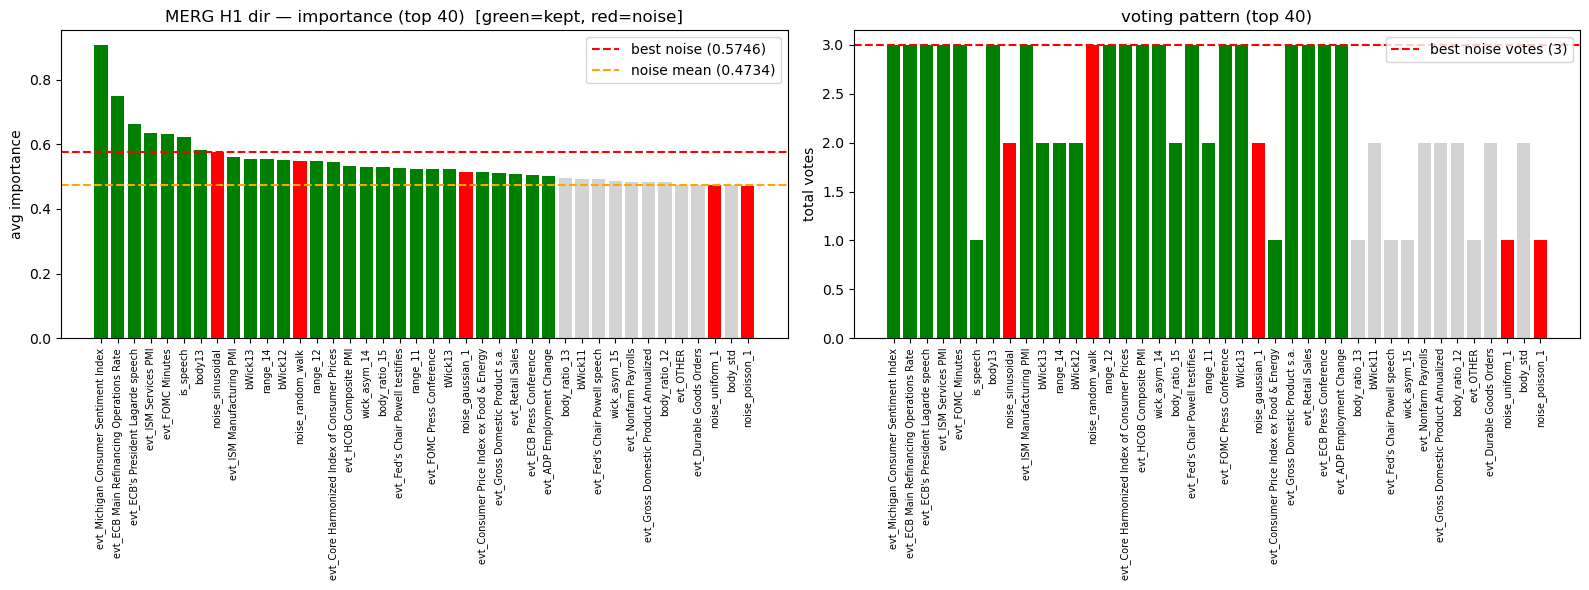

In [16]:
print("=" * 60)
print("FEATURE SELECTION RESULTS")
print("=" * 60)
print(f"Real features tested : {len(FEATURE_COLS) + len(EVENT_COLS)}")
print(f"Selected             : {len(selected_features)}")
print(f"Reduction            : {(1 - len(selected_features) / len(X_noise.columns)) * 100:.0f}%")
print(f"Best noise importance: {noise_df['avg_imp'].max():.5f}")

selected_report = imp_df[imp_df["feature"].isin(selected_features)]
print("\nTop 15 selected features:")
print(selected_report[["feature", "avg_imp", "total_votes"]].head(15).to_string(index=False))

event_survivors = [f for f in selected_features if f.startswith("evt_")]
print(f"\nEvent features that survived selection: {len(event_survivors)}")
if event_survivors:
    print(event_survivors)

top = imp_df.head(40)
colors = [
    "green" if f in selected_features else ("red" if n else "lightgray")
    for f, n in zip(top["feature"], top["is_noise"])
]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 6))
axL.bar(range(len(top)), top["avg_imp"], color=colors)
axL.axhline(noise_df["avg_imp"].max(), color="red", linestyle="--",
            label=f"best noise ({noise_df['avg_imp'].max():.4f})")
axL.axhline(noise_imp_mean, color="orange", linestyle="--",
            label=f"noise mean ({noise_imp_mean:.4f})")
axL.set_xticks(range(len(top)))
axL.set_xticklabels(top["feature"], rotation=90, fontsize=7)
axL.set_ylabel("avg importance")
axL.set_title(f"MERG H1 dir — importance (top 40)  [green=kept, red=noise]")
axL.legend()

axR.bar(range(len(top)), top["total_votes"], color=colors)
axR.axhline(noise_votes_max, color="red", linestyle="--",
            label=f"best noise votes ({noise_votes_max})")
axR.set_xticks(range(len(top)))
axR.set_xticklabels(top["feature"], rotation=90, fontsize=7)
axR.set_ylabel("total votes")
axR.set_title("voting pattern (top 40)")
axR.legend()
plt.tight_layout()
plt.show()


In [17]:
selected_report.to_csv(FEATURES_DIR / f"{PAIR}_MERG_v2_h1dir_selected_features.csv", index=False)
imp_df.to_csv(FEATURES_DIR / f"{PAIR}_MERG_v2_h1dir_feature_importance_full.csv", index=False)

print(f"✓ Saved {len(selected_features)} selected features to:")
print(f"  {FEATURES_DIR / f'{PAIR}_MERG_v2_h1dir_selected_features.csv'}")
print(f"\nselected_features ready for training ({len(selected_features)} columns).")


✓ Saved 25 selected features to:
  C:\Users\david\OneDrive\Documents\fx-prival\ml-signal-service\data\features\EURUSD_MERG_v2_h1dir_selected_features.csv

selected_features ready for training (25 columns).


In [18]:
selected_features

['evt_Michigan Consumer Sentiment Index',
 'evt_ECB Main Refinancing Operations Rate',
 "evt_ECB's President Lagarde speech",
 'evt_ISM Services PMI',
 'evt_FOMC Minutes',
 'is_speech',
 'body13',
 'evt_ISM Manufacturing PMI',
 'bWick13',
 'range_14',
 'bWick12',
 'range_12',
 'evt_Core Harmonized Index of Consumer Prices',
 'evt_HCOB Composite PMI',
 'wick_asym_14',
 'body_ratio_15',
 "evt_Fed's Chair Powell testifies",
 'range_11',
 'evt_FOMC Press Conference',
 'tWick13',
 'evt_Consumer Price Index ex Food & Energy',
 'evt_Gross Domestic Product s.a.',
 'evt_Retail Sales',
 'evt_ECB Press Conference',
 'evt_ADP Employment Change']

### 7.2 Model Selection

- **Outer CV** — purged expanding `TimeSeriesSplit` (train on past, test on future) with a
  `PURGE_DAYS` embargo so neighbouring events don't straddle a fold boundary.
- **Inner CV** — `TimeSeriesSplit` for hyperparameter search.
- **Recency weights** — recent years get more influence (markets drift).
- **Optimization metric** — **PR-AUC** (average precision), the right target for an imbalanced
  TP/SL problem.

Progression: **Logistic Regression** (baseline) → **Random Forest** → **XGBoost** → **LightGBM**.


In [19]:
X_train = df_train[selected_features].fillna(0)
y_train = df_train["y_sell_h1"].astype(int)
X_val = df_val[selected_features].fillna(0)
y_val = df_val["y_sell_h1"].astype(int)
X_test = df_test[selected_features].fillna(0)
y_test = df_test["y_sell_h1"].astype(int)

train_dates = pd.to_datetime(df_train["time"])
n_train = len(df_train)

outer_cv, fold_boundaries = [], []
block_size = n_train // (OUTER_FOLDS + 1)

for fold in range(OUTER_FOLDS):
    test_start_raw = block_size * (fold + 1)
    test_end_raw   = block_size * (fold + 2) if fold < OUTER_FOLDS - 1 else n_train
    last_train_date = train_dates.iloc[test_start_raw - 1]
    purge_threshold = last_train_date + pd.Timedelta(days=PURGE_DAYS)
    test_start = test_start_raw
    while test_start < test_end_raw and train_dates.iloc[test_start] < purge_threshold:
        test_start += 1
    if test_end_raw - test_start < 50:
        continue
    outer_cv.append((np.arange(0, test_start), np.arange(test_start, test_end_raw)))
    fold_boundaries.append((train_dates.iloc[test_start], train_dates.iloc[test_end_raw - 1]))

train_years = df_train["time"].dt.year.values

def time_decay_weights(years, decay=RECENCY_DECAY):
    years_ago = years.max() - years
    w = np.exp(-decay * years_ago)
    return w * len(w) / w.sum()

sample_weights = time_decay_weights(train_years)

print(f"Features : {len(selected_features)}")
print(f"Train    : {X_train.shape}  (SELL {y_train.mean()*100:.1f}%)")
print(f"Val      : {X_val.shape}  (SELL {y_val.mean()*100:.1f}%)")
print(f"Test     : {X_test.shape}  (sealed)")
print(f"Years    : {sorted(set(train_years))}")
print(f"Outer CV : purged expanding TimeSeriesSplit ({len(outer_cv)} folds)")
for i, (s, e) in enumerate(fold_boundaries):
    print(f"  fold {i+1} test: {s.strftime('%Y-%m-%d')} → {e.strftime('%Y-%m-%d')}")


Features : 25
Train    : (1235, 25)  (SELL 26.1%)
Val      : (299, 25)  (SELL 25.8%)
Test     : (656, 25)  (sealed)
Years    : [np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022)]
Outer CV : purged expanding TimeSeriesSplit (5 folds)
  fold 1 test: 2019-11-01 → 2020-06-10
  fold 2 test: 2020-07-14 → 2021-01-28
  fold 3 test: 2021-03-01 → 2021-09-10
  fold 4 test: 2021-10-13 → 2022-04-27
  fold 5 test: 2022-05-30 → 2022-12-23


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from xgboost import XGBClassifier

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "LogReg": {
        "model": Pipeline([
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
        ]),
        "params": {},
    },
    "RandomForest": {
        "model": RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [200, 400, 600],
            "max_depth": [10, 15, 20, None],
            "min_samples_leaf": [5, 10, 20, 50],
            "max_features": ["sqrt", "log2", 0.5],
        },
    },
    "XGBoost": {
        "model": XGBClassifier(
            random_state=42, n_jobs=-1, tree_method="hist",
            eval_metric="logloss", scale_pos_weight=pos_weight,
        ),
        "params": {
            "max_depth": [5, 7, 9, 11],
            "learning_rate": [0.05, 0.10, 0.20],
            "n_estimators": [150, 250, 400],
            "subsample": [0.7, 0.8, 0.9],
            "colsample_bytree": [0.7, 0.8, 0.9],
            "reg_lambda": [0.5, 1.0, 5.0],
        },
    },
    "LightGBM": {
        "model": lgb.LGBMClassifier(class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1),
        "params": {
            "max_depth": [6, 8, 10, 12],
            "num_leaves": [15, 31, 63, 127],
            "learning_rate": [0.05, 0.10, 0.20],
            "n_estimators": [150, 250, 400],
            "subsample": [0.8, 0.9, 1.0],
            "colsample_bytree": [0.7, 0.8, 0.9],
            "reg_lambda": [0.1, 0.5, 1.0, 5.0],
            "min_child_samples": [10, 20, 50],
        },
    },
}

INNER_CV = TimeSeriesSplit(n_splits=INNER_FOLDS)

print(f"Inner CV : TimeSeriesSplit({INNER_FOLDS})")
print(f"Search   : {SEARCH_ITERS} iters | optimizing PR-AUC (average_precision)")
print(f"XGB scale_pos_weight = {pos_weight:.2f}")


Inner CV : TimeSeriesSplit(4)
Search   : 60 iters | optimizing PR-AUC (average_precision)
XGB scale_pos_weight = 2.84


In [21]:
from sklearn.metrics import average_precision_score


def nested_cv(model, params, X, y, weights, name):
    outer_scores, best_params_per_fold = [], []
    for fold, (tr, te) in enumerate(outer_cv, 1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]
        w_tr = weights[tr]
        if params:
            search = RandomizedSearchCV(
                model, params, n_iter=SEARCH_ITERS, cv=INNER_CV,
                scoring="average_precision", n_jobs=-1, random_state=42,
            )
            search.fit(X_tr, y_tr, sample_weight=w_tr)
            best = search.best_estimator_
            best_params_per_fold.append(search.best_params_)
        else:
            best = model.fit(X_tr, y_tr)
            best_params_per_fold.append({})
        proba = best.predict_proba(X_te)[:, 1]
        outer_scores.append(average_precision_score(y_te, proba))
        print(f"   fold {fold}/{len(outer_cv)}  PR-AUC = {outer_scores[-1]:.3f}")
    print(f"   → {name}: PR-AUC {np.mean(outer_scores):.3f} ± {np.std(outer_scores):.3f}")
    return {
        "name": name,
        "pr_auc_mean": np.mean(outer_scores),
        "pr_auc_std": np.std(outer_scores),
        "best_params_per_fold": best_params_per_fold,
    }


print("✓ nested_cv() ready")


✓ nested_cv() ready


In [22]:
cv_results = {}
for name, cfg in models.items():
    print(f"\n{name}")
    cv_results[name] = nested_cv(
        cfg["model"], cfg["params"], X_train, y_train, sample_weights, name,
    )

comparison = (
    pd.DataFrame([
        {"model": r["name"], "pr_auc": r["pr_auc_mean"], "std": r["pr_auc_std"]}
        for r in cv_results.values()
    ])
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

baseline_pr = y_train.mean()
print("\n=== Model comparison (PR-AUC) ===")
print(comparison.round(3).to_string(index=False))
print(f"\nRandom baseline PR-AUC ≈ {baseline_pr:.3f} (positive rate)")

best_model_name = comparison.iloc[0]["model"]
print(f"\n🏆 Best model: {best_model_name}")



LogReg
   fold 1/5  PR-AUC = 0.397
   fold 2/5  PR-AUC = 0.336
   fold 3/5  PR-AUC = 0.399
   fold 4/5  PR-AUC = 0.372
   fold 5/5  PR-AUC = 0.353
   → LogReg: PR-AUC 0.371 ± 0.025

RandomForest
   fold 1/5  PR-AUC = 0.347
   fold 2/5  PR-AUC = 0.266
   fold 3/5  PR-AUC = 0.296
   fold 4/5  PR-AUC = 0.348
   fold 5/5  PR-AUC = 0.383
   → RandomForest: PR-AUC 0.328 ± 0.042

XGBoost
   fold 1/5  PR-AUC = 0.386
   fold 2/5  PR-AUC = 0.300
   fold 3/5  PR-AUC = 0.225
   fold 4/5  PR-AUC = 0.363
   fold 5/5  PR-AUC = 0.389
   → XGBoost: PR-AUC 0.333 ± 0.063

LightGBM
   fold 1/5  PR-AUC = 0.382
   fold 2/5  PR-AUC = 0.273
   fold 3/5  PR-AUC = 0.233
   fold 4/5  PR-AUC = 0.352
   fold 5/5  PR-AUC = 0.357
   → LightGBM: PR-AUC 0.320 ± 0.057

=== Model comparison (PR-AUC) ===
       model  pr_auc   std
      LogReg   0.371 0.025
     XGBoost   0.333 0.063
RandomForest   0.328 0.042
    LightGBM   0.320 0.057

Random baseline PR-AUC ≈ 0.261 (positive rate)

🏆 Best model: LogReg


In [23]:
MANUAL_MODEL = None
if MANUAL_MODEL is not None:
    if MANUAL_MODEL not in cv_results:
        raise ValueError(f"Unknown model '{MANUAL_MODEL}'. Choose from: {list(cv_results.keys())}")
    best_model_name = MANUAL_MODEL
    print(f"⚠ Manual override active → using {best_model_name}")
else:
    print(f"✓ Auto-selected best model → {best_model_name}")

chosen = cv_results[best_model_name]
print(f"\n  CV PR-AUC : {chosen['pr_auc_mean']:.3f} ± {chosen['pr_auc_std']:.3f}")
print(f"\nModel comparison for reference:")
print(comparison.round(3).to_string(index=False))


✓ Auto-selected best model → LogReg

  CV PR-AUC : 0.371 ± 0.025

Model comparison for reference:
       model  pr_auc   std
      LogReg   0.371 0.025
     XGBoost   0.333 0.063
RandomForest   0.328 0.042
    LightGBM   0.320 0.057


In [24]:
from collections import Counter
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix,
)

USE_CALIBRATION = True
USE_ENSEMBLE    = True
CALIB_CV        = 3


def most_frequent_params(params_list):
    final = {}
    for key in {k for p in params_list for k in p}:
        vals = [p[key] for p in params_list if key in p]
        final[key] = Counter(vals).most_common(1)[0][0]
    return final


def build_tuned(name):
    est = models[name]["model"]
    params = most_frequent_params(cv_results[name]["best_params_per_fold"])
    if params:
        est.set_params(**params)
    return est, params


def make_calibrated(est):
    return CalibratedClassifierCV(est, method="isotonic", cv=CALIB_CV) if USE_CALIBRATION else est


if USE_ENSEMBLE:
    estimators = []
    for name in models:
        base, params = build_tuned(name)
        estimators.append((name, make_calibrated(base)))
        print(f"  {name:<12} params: {params if params else '(baseline)'}")
    final_model = VotingClassifier(estimators=estimators, voting="soft", n_jobs=-1)
    final_model.fit(X_train, y_train)
    best_model_name = "Ensemble"
    print("\n✓ Final model = soft-vote ensemble of 4 calibrated models")
else:
    base, params = build_tuned(best_model_name)
    final_model = make_calibrated(base)
    try:
        final_model.fit(X_train, y_train, sample_weight=sample_weights)
    except TypeError:
        final_model.fit(X_train, y_train)
    print(f"Final hyperparameters: {params}")
    print(f"\n✓ Final model = {best_model_name}{' (calibrated)' if USE_CALIBRATION else ''}")

val_proba = final_model.predict_proba(X_val)[:, 1]
val_pred  = (val_proba >= 0.5).astype(int)

print(f"\n=== Validation performance (@0.5 ref) — {best_model_name} ===")
print(f"ROC-AUC   : {roc_auc_score(y_val, val_proba):.3f}")
print(f"PR-AUC    : {average_precision_score(y_val, val_proba):.3f}")
print(f"Precision : {precision_score(y_val, val_pred, zero_division=0):.3f}")
print(f"Recall    : {recall_score(y_val, val_pred, zero_division=0):.3f}")
print(f"F1        : {f1_score(y_val, val_pred, zero_division=0):.3f}")
print("\nConfusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_val, val_pred))


  LogReg       params: (baseline)
  RandomForest params: {'max_depth': 10, 'max_features': 0.5, 'n_estimators': 200, 'min_samples_leaf': 5}
  XGBoost      params: {'n_estimators': 250, 'reg_lambda': 1.0, 'colsample_bytree': 0.9, 'max_depth': 5, 'subsample': 0.9, 'learning_rate': 0.05}
  LightGBM     params: {'num_leaves': 63, 'n_estimators': 150, 'reg_lambda': 0.1, 'colsample_bytree': 0.8, 'max_depth': 6, 'min_child_samples': 10, 'subsample': 0.9, 'learning_rate': 0.05}

✓ Final model = soft-vote ensemble of 4 calibrated models

=== Validation performance (@0.5 ref) — Ensemble ===
ROC-AUC   : 0.630
PR-AUC    : 0.335
Precision : 0.000
Recall    : 0.000
F1        : 0.000

Confusion matrix (rows=true, cols=pred):
[[222   0]
 [ 77   0]]


### 7.3 Threshold Calibration

The TP/SL label is imbalanced (SL side wins more often). We pick the threshold that maximises
**F1** on validation, subject to a minimum-support floor. The gate at runtime uses a high-confidence
cutoff (`GATE_THRESHOLD = 0.60`) — the F1-optimal threshold is saved for reference.


Min signals floor : 20
Optimal threshold : 0.2188
Precision @ opt   : 0.3259
Recall    @ opt   : 0.9481
F1        @ opt   : 0.485
Signals           : 224

Top eligible thresholds (by F1):
 threshold  precision  recall  n_signals
    0.2188     0.3259  0.9481        224
    0.2181     0.3244  0.9481        225
    0.2172     0.3230  0.9481        226
    0.2159     0.3216  0.9481        227
    0.2193     0.3229  0.9351        223
    0.2156     0.3202  0.9481        228
    0.2123     0.3188  0.9481        229
    0.2116     0.3174  0.9481        230
    0.2195     0.3198  0.9221        222
    0.2062     0.3160  0.9481        231


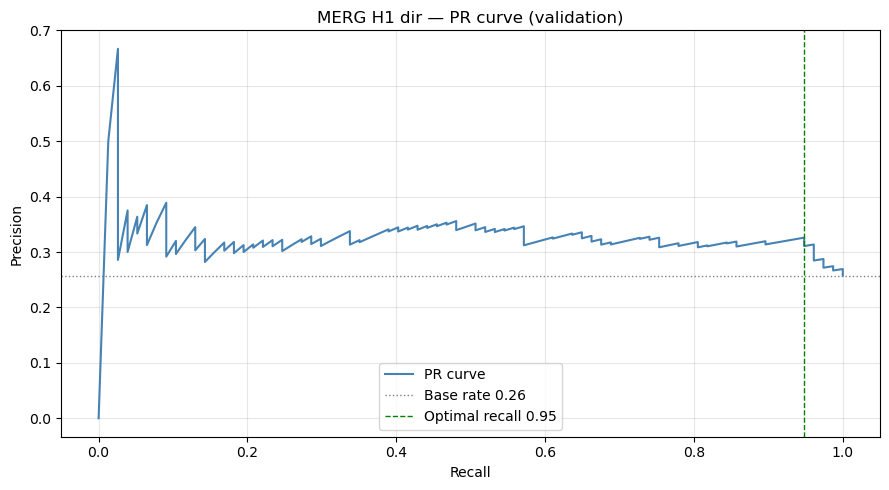


Gate threshold: 0.6  (F1-optimal was 0.2188, kept as threshold_f1_optimal in bundle)


In [25]:
from sklearn.metrics import precision_recall_curve

MIN_VAL_SIGNALS = 20   # smaller val set than Stage 1; lower the floor

precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba)

rows = []
for thr, p, r in zip(thresholds, precisions[:-1], recalls[:-1]):
    n_sig = int((val_proba >= thr).sum())
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    rows.append({"threshold": round(float(thr), 4), "precision": round(float(p), 4),
                 "recall": round(float(r), 4), "f1": round(float(f1), 4),
                 "n_signals": n_sig})
cal_df = pd.DataFrame(rows)

eligible = cal_df[cal_df["n_signals"] >= MIN_VAL_SIGNALS]
if not eligible.empty:
    best = eligible.sort_values("f1", ascending=False).iloc[0]
    OPTIMAL_THRESHOLD = float(best["threshold"])
    best_rec = best["recall"]
    print(f"Min signals floor : {MIN_VAL_SIGNALS}")
    print(f"Optimal threshold : {OPTIMAL_THRESHOLD}")
    print(f"Precision @ opt   : {best['precision']}")
    print(f"Recall    @ opt   : {best_rec}")
    print(f"F1        @ opt   : {best['f1']}")
    print(f"Signals           : {int(best['n_signals'])}")
    print("\nTop eligible thresholds (by F1):")
    print(eligible.sort_values("f1", ascending=False)
                .drop(columns="f1").head(10).to_string(index=False))
else:
    OPTIMAL_THRESHOLD = 0.5
    best_rec = 0.0
    print(f"⚠ No threshold reaches {MIN_VAL_SIGNALS} signals — falling back to 0.5.")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(recalls[:-1], precisions[:-1], color="steelblue", lw=1.5, label="PR curve")
ax.axhline(y_val.mean(), color="gray", ls=":", lw=1, label=f"Base rate {y_val.mean():.2f}")
ax.axvline(best_rec, color="green", ls="--", lw=1, label=f"Optimal recall {best_rec:.2f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title(f"MERG H1 dir — PR curve (validation)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nGate threshold: {GATE_THRESHOLD}  "
      f"(F1-optimal was {OPTIMAL_THRESHOLD}, kept as threshold_f1_optimal in bundle)")


SEALED TEST — Ensemble  (threshold=0.2188)
ROC-AUC : 0.598
PR-AUC  : 0.313
Precision @ threshold : 0.308
Recall    @ threshold : 0.875
F1        @ threshold : 0.455
Signals               : 478 / 656
Base rate             : 0.256

Confusion matrix (rows=true, cols=pred):
[[157 331]
 [ 21 147]]


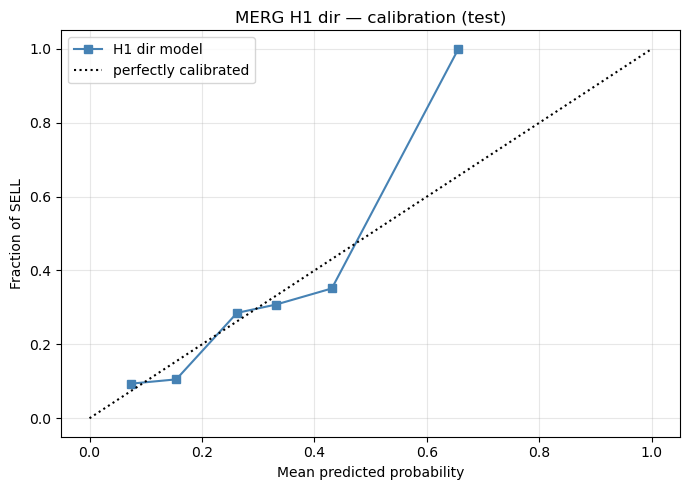


=== Test-set operating points (confidence sweep) ===
 threshold  precision   recall      F1  signals
--------------------------------------------------
      0.40      0.368    0.083   0.136       38
      0.45      0.273    0.018   0.034       11
      0.50      1.000    0.006   0.012        1
      0.55      1.000    0.006   0.012        1
      0.60      1.000    0.006   0.012        1
      0.65      1.000    0.006   0.012        1
      0.70          —        —       —        0

Per-event precision among *signals*, top 20 by count:
                                           n  correct  precision
event                                                           
Retail Sales                              81       18      0.222
ECB's President Lagarde speech            68       15      0.221
HCOB Composite PMI                        58       20      0.345
ADP Employment Change                     31        6      0.194
Core Harmonized Index of Consumer Prices  31       13      0.419
G

In [26]:
from sklearn.calibration import calibration_curve

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= OPTIMAL_THRESHOLD).astype(int)

print("=" * 60)
print(f"SEALED TEST — {best_model_name}  (threshold={OPTIMAL_THRESHOLD})")
print("=" * 60)
print(f"ROC-AUC : {roc_auc_score(y_test, test_proba):.3f}")
print(f"PR-AUC  : {average_precision_score(y_test, test_proba):.3f}")
print(f"Precision @ threshold : {precision_score(y_test, test_pred, zero_division=0):.3f}")
print(f"Recall    @ threshold : {recall_score(y_test, test_pred, zero_division=0):.3f}")
print(f"F1        @ threshold : {f1_score(y_test, test_pred, zero_division=0):.3f}")
print(f"Signals               : {test_pred.sum()} / {len(test_pred)}")
print(f"Base rate             : {y_test.mean():.3f}")
print("\nConfusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test, test_pred))

# ── Calibration curve ───────────────────────────────────────────────────────────
frac_pos, mean_pred = calibration_curve(y_test, test_proba, n_bins=10)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(mean_pred, frac_pos, "s-", color="steelblue", label="H1 dir model")
ax.plot([0, 1], [0, 1], "k:", label="perfectly calibrated")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Fraction of SELL")
ax.set_title(f"MERG H1 dir — calibration (test)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── Confidence-threshold sweep ─────────────────────────────────────────────────
print("\n=== Test-set operating points (confidence sweep) ===")
print(f"{'threshold':>10}{'precision':>11}{'recall':>9}{'F1':>8}{'signals':>9}")
print("-" * 50)
for thr in [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    pred = (test_proba >= thr).astype(int)
    n_sig = int(pred.sum())
    if n_sig == 0:
        print(f"{thr:>10.2f}{'—':>11}{'—':>9}{'—':>8}{n_sig:>9}")
        continue
    p = precision_score(y_test, pred, zero_division=0)
    r = recall_score(y_test, pred, zero_division=0)
    f = f1_score(y_test, pred, zero_division=0)
    print(f"{thr:>10.2f}{p:>11.3f}{r:>9.3f}{f:>8.3f}{n_sig:>9}")

# ── Per-event and speech breakdown ─────────────────────────────────────────────
test_eval = df_test[["time", "event"]].copy()
test_eval["y"]     = y_test.values
test_eval["proba"] = test_proba
test_eval["pred"]  = test_pred

per_event = (
    test_eval[test_eval["pred"] == 1]
    .groupby("event")
    .agg(n=("y", "size"), correct=("y", "sum"))
)
per_event["precision"] = per_event["correct"] / per_event["n"]
per_event = per_event.sort_values("n", ascending=False)
print("\nPer-event precision among *signals*, top 20 by count:")
print(per_event.head(20).round(3).to_string())

test_eval["is_speech"] = df_test["is_speech"].values
for thr, tag in [(OPTIMAL_THRESHOLD, "F1-optimal"), (GATE_THRESHOLD, "gate")]:
    print(f"\n=== Speech vs non-speech (threshold={thr:.4f} — {tag}) ===")
    for grp, sub in test_eval.groupby("is_speech"):
        label = "SPEECH" if grp else "NON-SPEECH"
        y_sub  = sub["y"].values
        p_sub  = sub["proba"].values
        pred_sub = (p_sub >= thr).astype(int)
        n_sig = int(pred_sub.sum())
        prec  = precision_score(y_sub, pred_sub, zero_division=0)
        rec   = recall_score(y_sub, pred_sub, zero_division=0)
        roc   = roc_auc_score(y_sub, p_sub)
        print(f"  {label:<12} n={len(sub):>4}  base_rate={y_sub.mean():.3f}  "
              f"ROC-AUC={roc:.3f}  signals={n_sig:>4}  precision={prec:.3f}  recall={rec:.3f}")


In [ ]:
import joblib

model_path = MODELS_DIR / f"{PAIR}_MERG_v2_h1dir_{best_model_name}.joblib"
joblib.dump(
    {
        "model": final_model,
        "features": selected_features,
        "threshold": GATE_THRESHOLD,
        "threshold_f1_optimal": OPTIMAL_THRESHOLD,
        "window_prefix": WINDOW_PREFIX,
        "event_top_k": top_k_events,
        "event_min_count": EVENT_MIN_COUNT,
        "forward_bars": FORWARD_BARS,
        "tp_multiplier": TP_MULTIPLIER,
        "sl_multiplier": SL_MULTIPLIER,
        "train_end": TRAIN_END,
        "val_end": VAL_END,
    },
    model_path,
)

print(f"✓ Saved model bundle → {model_path}")
print(f"  model         : {best_model_name}")
print(f"  features      : {len(selected_features)}")
print(f"  threshold     : {GATE_THRESHOLD}  (gate)")
print(f"  threshold_f1  : {OPTIMAL_THRESHOLD}  (reference)")
print(f"  window_prefix : {WINDOW_PREFIX}")


✓ Saved model bundle → C:\Users\david\OneDrive\Documents\fx-prival\ml-signal-service\models_bin\EURUSD_MERG_v2_h1dir_Ensemble.joblib
  model         : Ensemble
  features      : 25
  threshold     : 0.6  (gate)
  threshold_f1  : 0.2188  (reference)
  window_prefix : 5


: 

## Next Steps

This notebook produced the **H1 event-direction model**. If it shows signal on the sealed test,
the integration path is:

1. **Wire into the MERG gate** — `macro_event_responder.py` loads this bundle as a third model
   alongside Stage 1 (reaction). The gate flow:
   - H1 sell signal fires + event near + Stage 1 ≥ 0.60 → run this model
   - P(SELL over 6H) ≥ 0.60 → direction is DOWN → SELL aligned → PASS
   - Otherwise → BLOCK

2. **Extend the H1 data** — fetch EURUSD H1 bars from MT5 back to 2007 to double the training set
   (~5,000 events instead of ~2,500). This is worth doing if the seal-test signal is real.

3. **Calibrate the TP/SL multipliers** — tune `TP_MULTIPLIER` / `SL_MULTIPLIER` against the
   existing H1 SELL model's typical trade to keep the label consistent with production.

4. **Shadow phase** — deploy with `MERG_ENABLED=true, MERG_SHADOW_ONLY=true` and monitor
   `merg_shadow.log` for the event-direction decisions alongside the Stage-1 veto.
